# Market Regime Detection

In the previous notebooks, portfolio optimization was performed using a single set of mean return and covariance estimates computed over the full sample of hiatorical data. While this provides a useful baseline, financial markets do not behave the same way over time. Periods of strong growth, normal market conditions, and crisis-driven stress often exhibit different return dynamics, volatility levels, and relationships between assets.

This notebook introduces **market regime detection** as a way to account for those changing environments. The goal is to identify persistent hidden market states using a **Hidden Markov Model (HMM)** applied to features derived from the S&P 500 ETF (**SPY**). Regimes are modeled using two observable inputs: daily SPY returns and 20-day rolling volatility.

The intuition is that market behavior is not generated by one single, stable process. Instead, returns may evolve according to different underlying states such as a calm bullish regime, a normal transition regime, or a high-volatility crisis regime. By detecting those states, later notebooks can estimate regime-specific covariance matrices and construct portfolios tailored to different market environments.

More formally, instead of assuming that returns always come from one common distribution,

$$
r_t \sim \mathcal{N}(\mu, \Sigma),
$$

we allow the distribution of returns to depend on an unobserved regime variable $S_t$:

$$
r_t \mid S_t = k \sim \mathcal{N}(\mu_k, \Sigma_k),
$$

where $S_t$ represents the market regime at time $t$, and each regime $k$ has its own characteristic return and risk structure.

The purpose of this notebook is therefore to:

1. explain the intuition and mechanics of Hidden Markov Models,
2. construct regime-detection features from SPY,
3. fit a 3-state HMM to historical market data,
4. decode the most likely regime at each point in time,
5. interpret and label the detected regimes, and
6. save the resulting regime series for use in later portfolio construction and backtesting notebooks.

This notebook serves as the bridge between the static portfolio optimization framework developed earlier and the dynamic, regime-aware allocation strategy that follows.

## Hidden Markov Models for Market Regime Detection

A **Hidden Markov Model (HMM)** is a statistical model used to describe systems that evolve through a sequence of unobserved (hidden) states over time. Although the states themselves are not directly observable, they influence the observable data generated by the system.

In the context of financial markets, we can think of the market as switching between different **regimes**. These regimes cannot be observed directly, but they affect observable quantities such as returns and volatility.

An HMM models this structure by introducing two components:

- a **hidden state process** representing the underlying regime
- an **observation process** representing the data we can measure

Let $S_t$ denote the hidden regime at time $t$, and let $X_t$ denote the observed feature vector derived from market data.

The model assumes that the hidden regimes evolve according to a **Markov process**, meaning the next regime depends only on the current regime:

$$
P(S_t \mid S_{t-1}, S_{t-2}, \dots) = P(S_t \mid S_{t-1})
$$

This property implies that the system's future state depends only on its present state, not on the full history of past states.

The probabilities governing transitions between regimes are summarized in the **transition matrix**

$$
A =
\begin{bmatrix}
P_{11} & P_{12} & P_{13} \\
P_{21} & P_{22} & P_{23} \\
P_{31} & P_{32} & P_{33}
\end{bmatrix}
$$

where $P_{ij} = P(S_t = j \mid S_{t-1} = i)$. Each row of this matrix represents the probabilities of moving from one regime to another in the next time step.

In addition to the hidden regime process, the model specifies how the observed data are generated. Conditional on the current regime, the observed features are assumed to follow a probability distribution. In this project we assume a **multivariate Gaussian distribution**

$$
X_t \mid S_t = k \sim \mathcal{N}(\mu_k, \Sigma_k)
$$

where:

- $X_t$ is the observed feature vector at time $t$
- $k$ is the regime index
- $\mu_k$ is the mean vector associated with regime $k$
- $\Sigma_k$ is the covariance matrix associated with regime $k$

For regime detection in this project, the observation vector $X_t$ will consist of two market features derived from the S&P 500 ETF (SPY):

$$
X_t =
\begin{bmatrix}
\text{SPY return}_t \\
\text{SPY rolling volatility}_t
\end{bmatrix}
$$

These features capture both **market direction** and **market risk**, allowing the model to distinguish between different types of market environments.

Once the HMM is fitted to historical data, the model can infer the most likely sequence of hidden regimes that generated the observed market behavior. These inferred regimes will then be used in later notebooks to estimate regime-specific return and covariance structures for portfolio construction.

## Data Preparation for Regime Detection

To detect market regimes, the Hidden Markov Model requires a time series of observable features that reflect changing market conditions. In this project, the regime model is based on two features derived from SPY:

- daily returns, which capture market direction
- 20-day rolling volatility, which captures recent market risk

Using both features allows the model to distinguish between environments that differ not only in return behavior, but also in the intensity of market fluctuations.

Let the daily return of SPY at time \(t\) be

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}},
$$

and let the 20-day rolling volatility be

$$
\sigma_t = \sqrt{\frac{1}{20}\sum_{i=1}^{20}(r_{t-i} - \bar r)^2}.
$$

These two quantities form the observation vector used by the HMM:

$$
X_t =
\begin{bmatrix}
r_t \\
\sigma_t
\end{bmatrix}.
$$

The following steps load the return data, construct these features, and organize them into a clean dataset for regime modeling.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
import json
from pathlib import Path

returns = pd.read_csv(
    "../data/processed/asset_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,EFA,GLD,SPY,TLT,VNQ
Date,,,,,
2010-01-05,0.000881,-0.000911,0.002644,0.006438,-0.001123
2010-01-06,0.004218,0.016365,0.000704,-0.013477,-0.001800
2010-01-07,-0.003866,-0.006207,0.004212,0.001680,0.010749
2010-01-08,0.007891,0.004951,0.003322,-0.000447,-0.007377
2010-01-11,0.008176,0.013201,0.001396,-0.005503,0.005817


In [3]:
# Extract SPY returns
spy_returns = returns["SPY"].copy()

spy_returns.head()

Date
2010-01-05    0.002644
2010-01-06    0.000704
2010-01-07    0.004212
2010-01-08    0.003322
2010-01-11    0.001396
Name: SPY, dtype: float64

In [ ]:
# Compute 20-day rolling volatility
rolling_vol = spy_returns.rolling(window=20).std()

rolling_vol.tail()

Date
2026-03-03    0.008309
2026-03-04    0.008307
2026-03-05    0.008330
2026-03-06    0.008379
2026-03-09    0.007383
Name: SPY, dtype: float64

In [ ]:
# Combine featues into a single DataFrame for HMM
hmm_data = pd.DataFrame({
    "SPY_return": spy_returns,
    "SPY_volatility": rolling_vol
})

# drop initial NaNs from rolling window
hmm_data = hmm_data.dropna()

hmm_data.head()

,SPY_return,SPY_volatility
Date,,
2010-02-02,0.012031,0.010618
2010-02-03,-0.004995,0.010606
2010-02-04,-0.031352,0.012480
2010-02-05,0.002064,0.012421
2010-02-08,-0.007245,0.012344


Before fitting the model, we can visualize these series to confirm the presence of volatility clustering and periods of elevated market stress that the HMM will attempt to identify as distinct regimes.

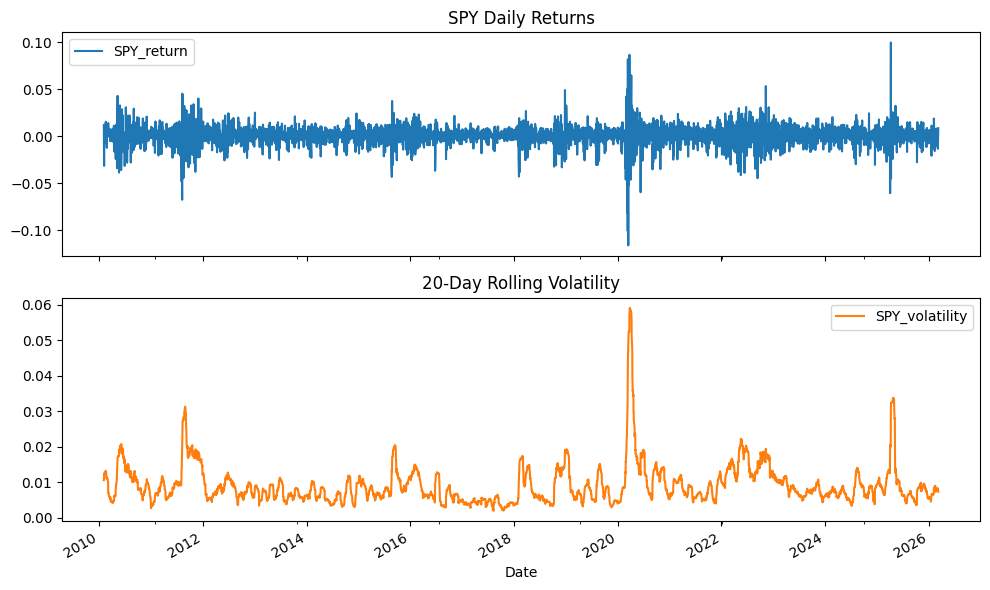

In [ ]:
hmm_data.plot(
    subplots=True,
    figsize=(10,6),
    title=["SPY Daily Returns", "20-Day Rolling Volatility"]
)

plt.tight_layout()

## Fitting the Hidden Markov Model

With the feature dataset prepared, we can now estimate a Hidden Markov Model to identify latent market regimes.

The model assumes that the market evolves through a sequence of hidden states $S_t$ that follow a Markov process. Each state represents a distinct market environment characterized by its own statistical properties.


The model therefore learns:

- the **transition probabilities** between regimes
- the **mean behavior of the observed features in each regime**
- the **covariance structure of the features within each regime**

In this implementation, we estimate a model with **three hidden states**, which allows the model to capture a low-volatility regime, a moderate regime, and a high-volatility regime.

The parameters of the model are estimated using the **Expectation–Maximization (EM)** algorithm, which iteratively updates the state probabilities and model parameters to maximize the likelihood of the observed data.

In [9]:
# Convert feature dataframe to numpy array for HMM
X = hmm_data.values

# Number of hidden regimes
n_states = 3

# Initialize model
hmm_model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

# Fit model to SPY return + rolling volatility features
hmm_model.fit(X)

# Decode most likely hidden state sequence
regimes = hmm_model.predict(X)

# Add decoded regimes back to dataframe
hmm_data["regime"] = regimes

# Quick checks
print("Feature matrix shape:", X.shape)
print("\nRegime counts:")
print(hmm_data["regime"].value_counts().sort_index())

print("\nTransition matrix:")
print(pd.DataFrame(
    hmm_model.transmat_,
    index=[f"From_State_{i}" for i in range(n_states)],
    columns=[f"To_State_{i}" for i in range(n_states)]
))

hmm_data.head()

Feature matrix shape: (4049, 2)

Regime counts:
regime
0      93
1    2772
2    1184
Name: count, dtype: int64

Transition matrix:
                To_State_0    To_State_1  To_State_2
From_State_0  9.658107e-01  2.289499e-38    0.034189
From_State_1  1.465056e-30  9.925453e-01    0.007455
From_State_2  2.700807e-03  1.839434e-02    0.978905


,SPY_return,SPY_volatility,regime
Date,,,
2010-02-02,0.012031,0.010618,2
2010-02-03,-0.004995,0.010606,2
2010-02-04,-0.031352,0.012480,2
2010-02-05,0.002064,0.012421,2
2010-02-08,-0.007245,0.012344,2


### Interpreting the Fitted HMM

After fitting the Hidden Markov Model, each observation is assigned to one of three latent states. At this stage, the states are identified only by numerical labels such as 0, 1, and 2. These labels do not yet have an economic interpretation; they simply represent distinct statistical patterns discovered by the model.

Two aspects of the fitted model are especially important. First, the **Regime counts** show how frequently each regime appears in the sample. Second, the **transition matrix** shows how persistent each regime is over time. The large diagonal entries in the transition matrix indicate that once the market enters a regime, it tends to remain there for a period of time rather than switching randomly from day to day. This is an encouraging result, since market regimes are generally understood as persistent environments rather than isolated one-day events.

The next step is to determine what each hidden state represents in economic terms. To do that, the summary statistics of each state are examined.

#### Regime Statistics

In [10]:
regime_stats = hmm_data.groupby("regime").agg({
    "SPY_return": ["mean", "std"],
    "SPY_volatility": ["mean"]
})

regime_stats

SPY_return           SPY_volatility
             mean       std           mean
regime                                    
0       -0.000851  0.036566       0.034482
1        0.000861  0.006592       0.006544
2       -0.000163  0.013962       0.013569

#### Economic Interpretation of the Hidden States

The regime statistics provide a way to translate the model's numerical states into meaningful market environments. For each hidden state, the table reports the average daily SPY return, the standard deviation of daily returns, and the average level of 20-day rolling volatility.

The results suggest a very natural three-regime structure:

- One state has **positive average returns and the lowest volatility**, which is consistent with a **bull or calm market regime**.
- One state has **slightly negative average returns and moderate volatility**, which is consistent with a **neutral or transitional regime**.
- One state has the **most negative returns and the highest volatility by a wide margin**, which is consistent with a **crisis regime**.

This interpretation is economically intuitive. In calm markets, returns tend to drift upward while volatility remains contained. In transitional or uncertain periods, returns weaken and volatility rises. In crisis periods, returns become sharply negative and volatility spikes.

**It is important to note that the HMM does not know these labels in advance. It only identifies statistically distinct states in the data. The labels are assigned afterward based on the behavior of returns and volatility within each state.**

#### Assigning Descriptive Regime Labels

Because the HMM states are arbitrary numerical identifiers, they must be mapped to descriptive labels after estimation. Based on the regime statistics above, the hidden states will be labeled as **Bull**, **Neutral**, and **Crisis**.

This relabeling step makes the results easier to interpret and prepares the regime series for later portfolio construction, where each regime will be associated with its own return and covariance structure.

In [11]:
regime_labels = {
    1: "Bull",
    2: "Neutral",
    0: "Crisis"
}

hmm_data["regime_label"] = hmm_data["regime"].map(regime_labels)

# Preview labeled dataset
hmm_data.head()

,SPY_return,SPY_volatility,regime,regime_label
Date,,,,
2010-02-02,0.012031,0.010618,2,Neutral
2010-02-03,-0.004995,0.010606,2,Neutral
2010-02-04,-0.031352,0.012480,2,Neutral
2010-02-05,0.002064,0.012421,2,Neutral
2010-02-08,-0.007245,0.012344,2,Neutral


## Visualizing the Detected Market Regimes

With the hidden states now mapped to economically meaningful labels, the final step is to visualize how these regimes evolve through time. A regime-colored market plot makes it possible to see whether the model is identifying persistent periods of calm markets, elevated uncertainty, and crisis-driven stress in a way that aligns with major episodes in financial history.

This visualization is especially useful because it moves the analysis from abstract statistical states to an intuitive picture of changing market environments. It also provides a connection to the next stage of the project, where these regime assignments will be used to estimate regime-specific covariance matrices and construct dynamic portfolios.

In [ ]:
# Load SPY price series and allign dates
prices = pd.read_csv(
    "../data/processed/asset_prices.csv",
    index_col=0,
    parse_dates=True
)

spy_price = prices["SPY"].copy()

# align to hmm_data dates
plot_data = hmm_data.copy()
plot_data["SPY_price"] = spy_price.reindex(plot_data.index)

plot_data.head()

,SPY_return,SPY_volatility,regime,regime_label,SPY_price
Date,,,,,
2010-02-02,0.012031,0.010618,2,Neutral,82.814659
2010-02-03,-0.004995,0.010606,2,Neutral,82.402023
2010-02-04,-0.031352,0.012480,2,Neutral,79.858635
2010-02-05,0.002064,0.012421,2,Neutral,80.023643
2010-02-08,-0.007245,0.012344,2,Neutral,79.445976


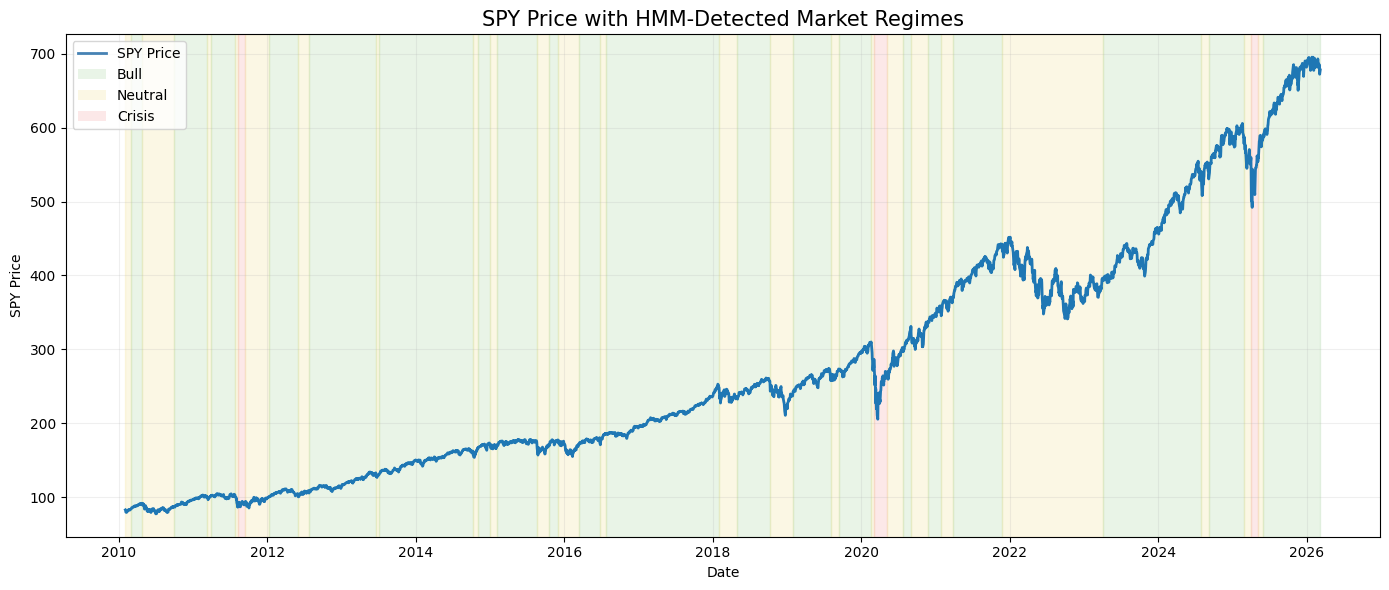

In [14]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 6))

# Plot SPY price
ax.plot(plot_data.index, plot_data["SPY_price"], linewidth=2, label="SPY Price", zorder=3)

# Softer colors
regime_colors = {
    "Bull": "#a8d5a2",     # soft green
    "Neutral": "#f2e394",  # soft yellow
    "Crisis": "#f4a6a6"    # soft red
}

# Shade contiguous regime segments
current_regime = plot_data["regime_label"].iloc[0]
start_idx = plot_data.index[0]

for i in range(1, len(plot_data)):
    regime_now = plot_data["regime_label"].iloc[i]
    if regime_now != current_regime:
        end_idx = plot_data.index[i]
        ax.axvspan(start_idx, end_idx, color=regime_colors[current_regime], alpha=0.25, zorder=1)
        start_idx = plot_data.index[i]
        current_regime = regime_now

# Final segment
ax.axvspan(start_idx, plot_data.index[-1], color=regime_colors[current_regime], alpha=0.25, zorder=1)

# Custom legend
legend_handles = [
    Line2D([0], [0], color="steelblue", lw=2, label="SPY Price"),
    Patch(facecolor=regime_colors["Bull"], alpha=0.25, label="Bull"),
    Patch(facecolor=regime_colors["Neutral"], alpha=0.25, label="Neutral"),
    Patch(facecolor=regime_colors["Crisis"], alpha=0.25, label="Crisis")
]

ax.set_title("SPY Price with HMM-Detected Market Regimes", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("SPY Price")
ax.legend(handles=legend_handles, loc="upper left")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interpretation

The regime-colored price chart provides a visual interpretation of the Hidden Markov Model classification. Each background color corresponds to one of the latent market states identified by the model, allowing the statistical output of the HMM to be compared directly with the historical evolution of the market.

Several patterns emerge from the visualization. Long stretches of green correspond to periods of relatively stable market growth, where volatility remains low and returns tend to be positive. These regions are consistent with the **bull regime**, which dominates much of the sample period. Yellow segments appear during periods of elevated uncertainty or market consolidation, where volatility increases and returns become less consistently positive. These intervals represent the **neutral regime** identified by the model.

Short red intervals highlight periods of extreme market stress. These correspond to the **crisis regime**, characterized by sharply elevated volatility and negative returns. The model identifies these regimes during major market disruptions, including the sharp volatility spike surrounding the 2020 COVID-19 market crash.

Overall, the detected regimes exhibit the persistence expected of real financial market environments: bull markets tend to persist for long periods, transitional regimes occur intermittently, and crisis regimes appear only briefly but are associated with the most dramatic market movements.

In [21]:
# Save regime detection outputs
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

# Save market regimes
market_regimes = hmm_data[["regime", "regime_label"]].copy()
market_regimes.to_csv(results_dir / "market_regimes.csv")

# Save regime statistics
regime_stats.columns = ["_".join(col).strip() for col in regime_stats.columns]
regime_stats.to_csv(results_dir / "regime_statistics.csv")

# Save transition matrix
transition_matrix = pd.DataFrame(
    hmm_model.transmat_,
    index=[f"From_State_{i}" for i in range(n_states)],
    columns=[f"To_State_{i}" for i in range(n_states)]
)
transition_matrix.to_csv(results_dir / "regime_transition_matrix.csv")

# Save full HMM feature dataset (optional but useful)
hmm_data.to_csv(results_dir / "hmm_feature_data_with_regimes.csv")

# Save metadata
regime_metadata = {
    "model": "GaussianHMM",
    "n_states": n_states,
    "features": ["SPY_return", "SPY_volatility"],
    "volatility_window": 20,
    "random_state": 42,
    "covariance_type": "full"
}

with open(results_dir / "regime_detection_metadata.json", "w") as f:
    json.dump(regime_metadata, f, indent=4)

---

## Summary and Next Steps

This notebook introduced a Hidden Markov Model framework for identifying latent market regimes using SPY returns and 20-day rolling volatility. The fitted model detected three persistent states that were interpreted as **Bull**, **Neutral**, and **Crisis** regimes based on their return and volatility characteristics.

The results show that market behavior is not well described by a single stationary distribution. Instead, distinct market environments emerge with different levels of volatility and return dynamics. This provides a strong motivation for moving beyond static portfolio optimization and toward a regime-aware allocation framework.

In the next notebook, these regime labels will be combined with the multi-asset return data to estimate **regime-specific mean returns and covariance matrices**. Those estimates will then be used to construct different optimal portfolios for different market environments.